## 1. Setup

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from divvy_demand.infra.s3_client import S3Client
from divvy_demand.utils import test_stationarity, plot_ts, compare_ts, plot_acf_pacf

load_dotenv("../.env")
s3 = S3Client(env="prod")

overall = s3.read_processed("overall")
overall["date"] = pd.to_datetime(overall["date"])
overall = overall.set_index("date").sort_index()

station = s3.read_processed("station")
station["date"] = pd.to_datetime(station["date"])

print("Overall:", overall.shape)
print("Station:", station.shape)

Overall: (2249, 4)
Station: (1404660, 7)


In [63]:
overall.head()

,total_rides,ebike_rides,member_rides,casual_rides
date,,,,
2020-01-01,2141,0,1664,477
2020-01-02,6479,0,5816,663
2020-01-03,5890,0,5437,453
2020-01-04,3187,0,2797,390
2020-01-05,3035,0,2604,431


In [64]:
overall.describe()

,total_rides,ebike_rides,member_rides,casual_rides
count,2249.000000,2249.000000,2249.000000,2249.000000
mean,14351.679858,6751.875056,8796.474433,5555.299244
std,8919.416826,4919.591752,4582.680896,4891.893670
min,193.000000,0.000000,15.000000,35.000000
25%,6314.000000,2648.000000,4876.000000,1416.000000
50%,13179.000000,5953.000000,8564.000000,4047.000000
75%,22527.000000,10753.000000,12791.000000,8774.000000
max,37328.000000,20093.000000,19414.000000,23517.000000


In [65]:
overall.isnull().sum()

total_rides     0
ebike_rides     0
member_rides    0
casual_rides    0
dtype: int64

## 2. Overall
### 2.1 Daily Rides Time Series

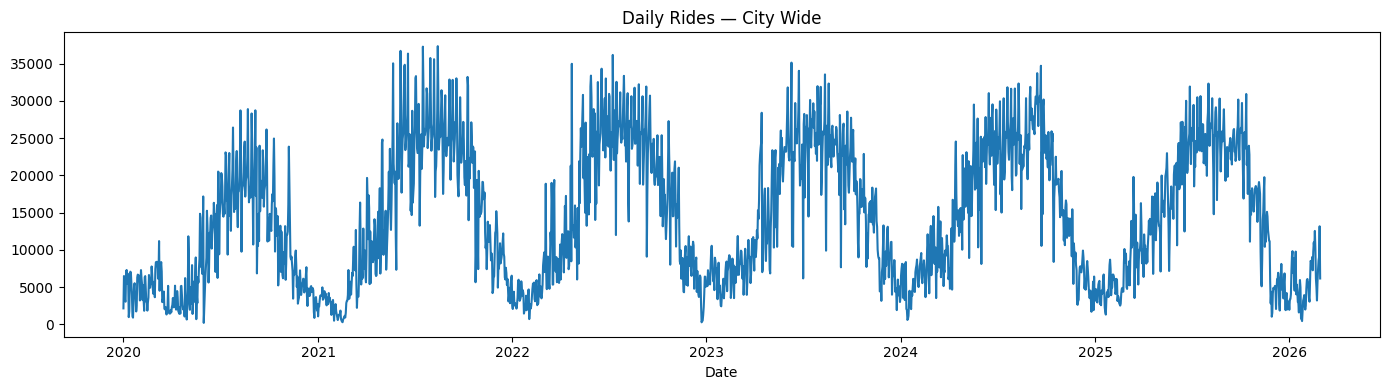

In [66]:
plot_ts(overall["total_rides"], title="Daily Rides — City Wide")

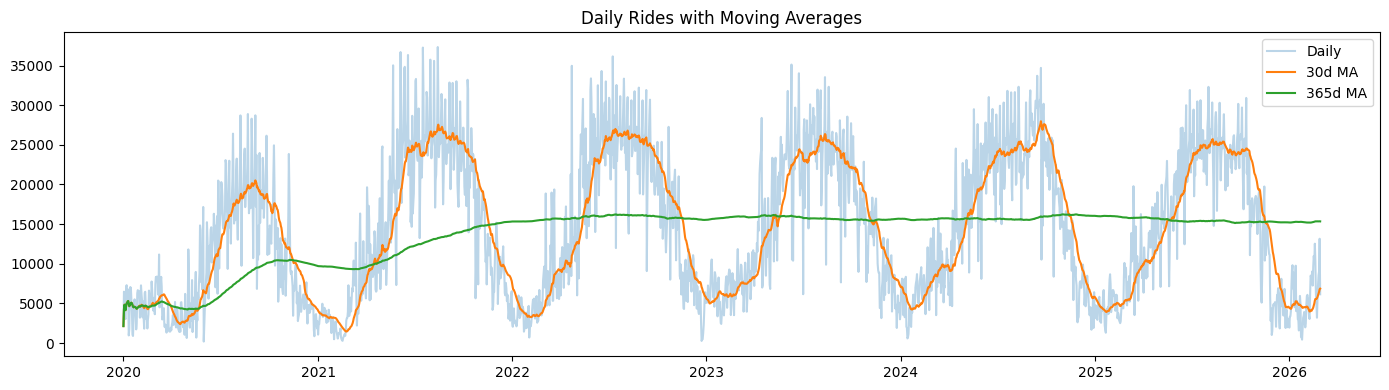

In [67]:
# 30-day and 365-day moving averages
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(overall.index, overall["total_rides"], alpha=0.3, label="Daily")
ax.plot(overall.index, overall["total_rides"].rolling(30, min_periods=1).mean(), label="30d MA")
ax.plot(overall.index, overall["total_rides"].rolling(365, min_periods=1).mean(), label="365d MA")
ax.set_title("Daily Rides with Moving Averages")
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Bike Type Breakdown

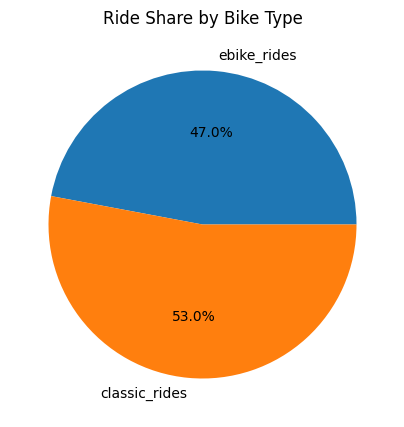

In [68]:
# Overall proportion
totals = overall[["ebike_rides", "member_rides"]].copy()
totals["classic_rides"] = overall["total_rides"] - overall["ebike_rides"]
pie_data = totals[["ebike_rides", "classic_rides"]].sum()
pie_data.plot.pie(autopct="%1.1f%%", figsize=(5, 5), title="Ride Share by Bike Type")
plt.ylabel("")
plt.show()

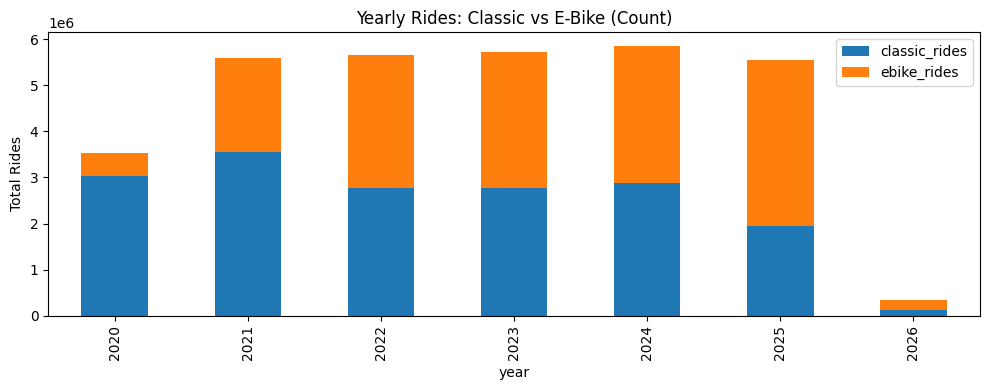

In [69]:
# Yearly e-bike vs classic stacked bar (count)
overall_reset = overall.reset_index()
overall_reset["year"] = overall_reset["date"].dt.year
overall_reset["classic_rides"] = overall_reset["total_rides"] - overall_reset["ebike_rides"]

yearly_bike = overall_reset.groupby("year")[["classic_rides", "ebike_rides"]].sum()
yearly_bike.plot.bar(stacked=True, figsize=(10, 4), title="Yearly Rides: Classic vs E-Bike (Count)")
plt.ylabel("Total Rides")
plt.tight_layout()
plt.show()

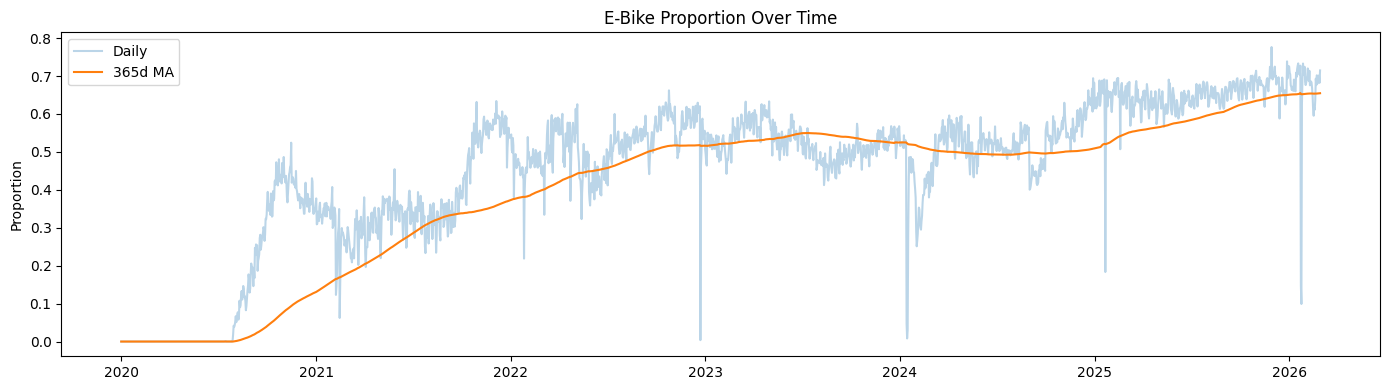

In [70]:
# E-bike proportion over time (365d MA)
ebike_prop = overall["ebike_rides"] / overall["total_rides"]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(overall.index, ebike_prop, alpha=0.3, label="Daily")
ax.plot(overall.index, ebike_prop.rolling(365, min_periods=1).mean(), label="365d MA")
ax.set_title("E-Bike Proportion Over Time")
ax.set_ylabel("Proportion")
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Membership Breakdown

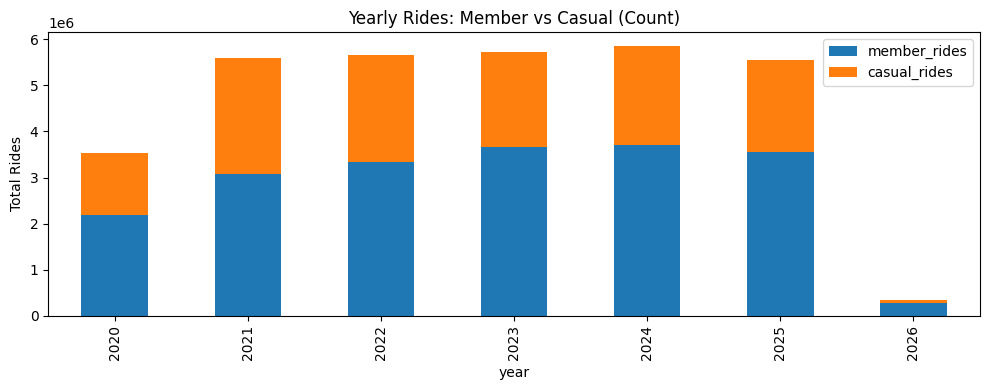

In [71]:
# Member vs casual by year — stacked count
overall_reset["year"] = overall_reset["date"].dt.year
yearly_mem = overall_reset.groupby("year")[["member_rides", "casual_rides"]].sum()
yearly_mem.plot.bar(stacked=True, figsize=(10, 4), title="Yearly Rides: Member vs Casual (Count)")
plt.ylabel("Total Rides")
plt.tight_layout()
plt.show()

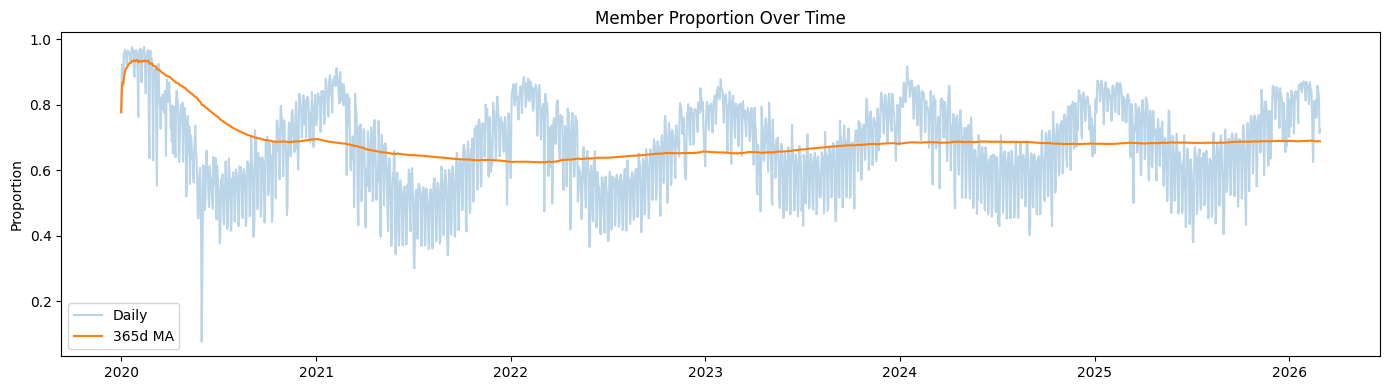

In [72]:
# Member proportion 365d MA
member_prop = overall["member_rides"] / overall["total_rides"]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(overall.index, member_prop, alpha=0.3, label="Daily")
ax.plot(overall.index, member_prop.rolling(365, min_periods=1).mean(), label="365d MA")
ax.set_title("Member Proportion Over Time")
ax.set_ylabel("Proportion")
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Day-of-Week Seasonality

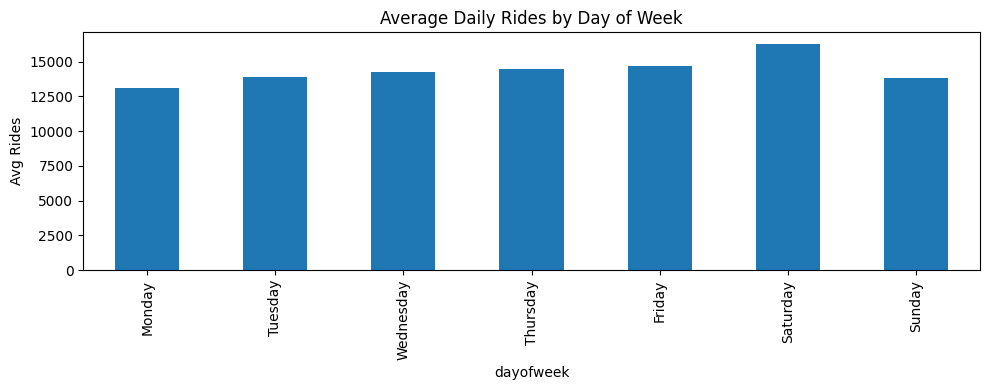

In [73]:
overall_reset = overall.reset_index()
overall_reset["dayofweek"] = overall_reset["date"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

overall_reset.groupby("dayofweek")["total_rides"].mean().reindex(dow_order).plot.bar(
    figsize=(10, 4), title="Average Daily Rides by Day of Week"
)
plt.ylabel("Avg Rides")
plt.tight_layout()
plt.show()

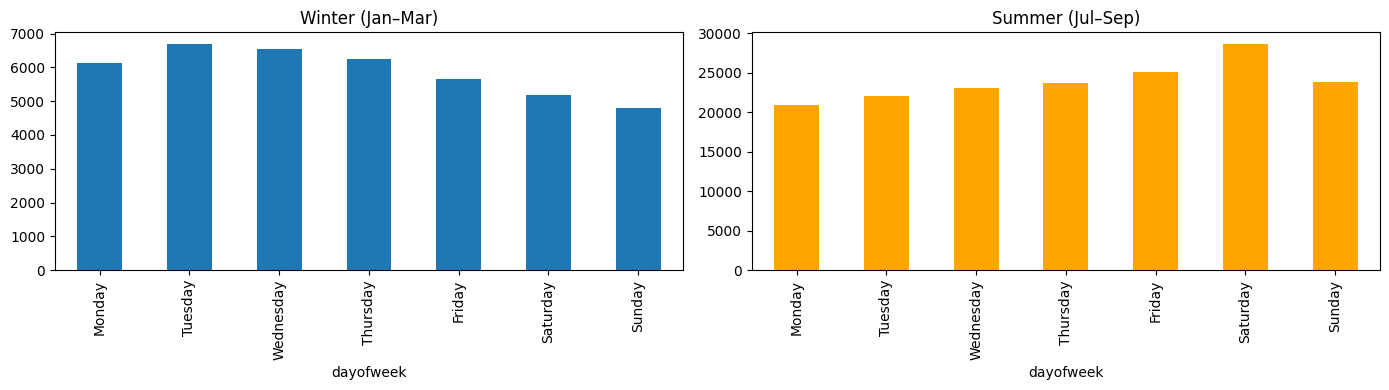

In [74]:
# Winter (Jan-Mar) vs Summer (Jul-Sep)
overall_reset["month"] = overall_reset["date"].dt.month
winter = overall_reset[overall_reset["month"].isin([1, 2, 3])]
summer = overall_reset[overall_reset["month"].isin([7, 8, 9])]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
winter.groupby("dayofweek")["total_rides"].mean().reindex(dow_order).plot.bar(ax=axes[0], title="Winter (Jan–Mar)")
summer.groupby("dayofweek")["total_rides"].mean().reindex(dow_order).plot.bar(ax=axes[1], title="Summer (Jul–Sep)", color="orange")
plt.tight_layout()
plt.show()

In [75]:
# Winter vs Summer stats by year
overall_reset["year"] = overall_reset["date"].dt.year
overall_reset["month"] = overall_reset["date"].dt.month
overall_reset["season"] = overall_reset["month"].apply(
    lambda m: "winter" if m in [1, 2, 3] else ("summer" if m in [7, 8, 9] else None)
)
seasonal = overall_reset.dropna(subset=["season"])
seasonal.groupby(["year", "season"])["total_rides"].agg(mean="mean", std="std").round(0)

mean     std
year season                 
2020 summer  18552.0  4421.0
     winter   4691.0  2267.0
2021 summer  25901.0  4531.0
     winter   4166.0  3225.0
2022 summer  25117.0  4556.0
     winter   5594.0  3827.0
2023 summer  23975.0  4809.0
     winter   7105.0  2202.0
2024 summer  25279.0  4465.0
     winter   7360.0  3291.0
2025 summer  24656.0  3001.0
     winter   6541.0  3524.0
2026 winter   5749.0  3041.0

## 3. Stationarity

In [76]:
test_stationarity(overall["total_rides"], "raw")

Stationarity Tests [raw]
---------------------------------------------
ADF  stat=-2.5316  p=0.1080  → non-stationary
KPSS stat=0.3653  p=0.0921  → stationary



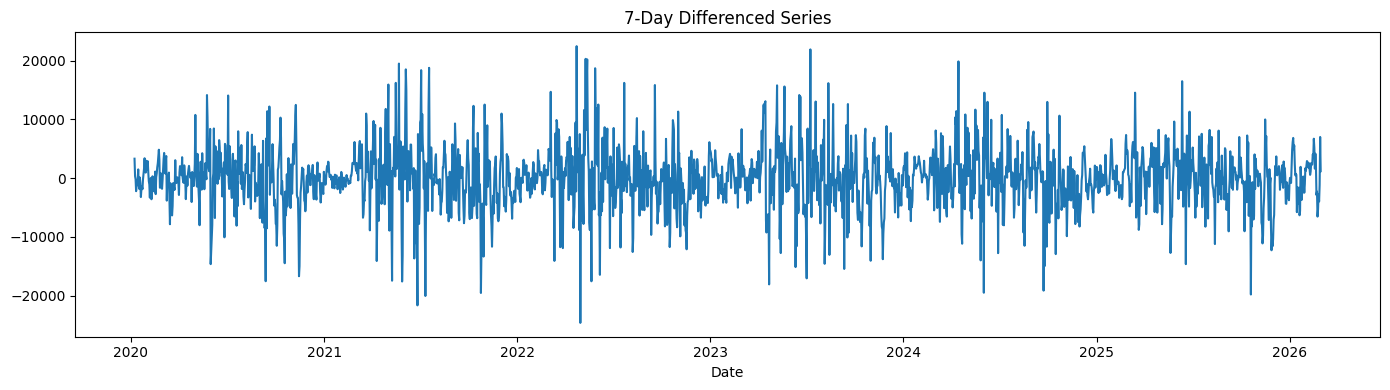

Stationarity Tests [diff(7)]
---------------------------------------------
ADF  stat=-8.2208  p=0.0000  → stationary
KPSS stat=0.0761  p=0.1000  → stationary



/Users/zimenghuang/Desktop/codes/hobby_projects/Divvy/divvy/src/divvy_demand/utils.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")


In [77]:
# 7-day difference
diff_7 = overall["total_rides"].diff(7)
plot_ts(diff_7.dropna(), title="7-Day Differenced Series")
test_stationarity(diff_7, "diff(7)")

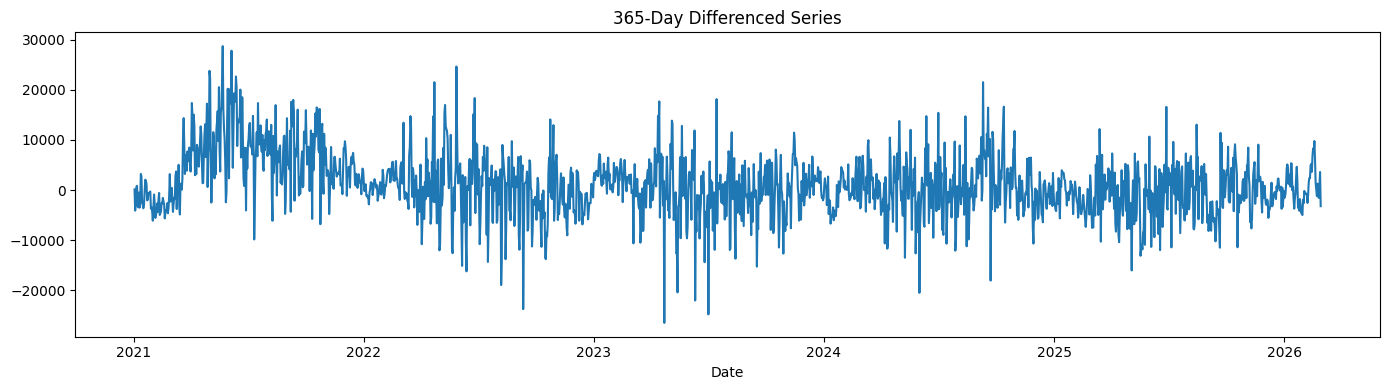

Stationarity Tests [diff(365)]
---------------------------------------------
ADF  stat=-4.2041  p=0.0006  → stationary
KPSS stat=2.2102  p=0.0100  → non-stationary



/Users/zimenghuang/Desktop/codes/hobby_projects/Divvy/divvy/src/divvy_demand/utils.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")


In [78]:
# 365-day difference
diff_365 = overall["total_rides"].diff(365)
plot_ts(diff_365.dropna(), title="365-Day Differenced Series")
test_stationarity(diff_365, "diff(365)")

## 4. ACF / PACF

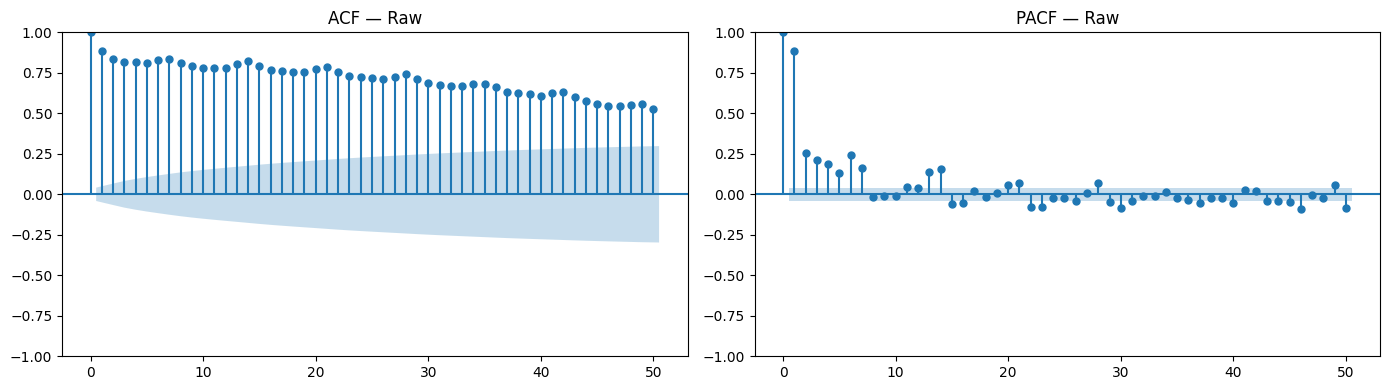

In [79]:
plot_acf_pacf(overall["total_rides"], lags=50, title="Raw")

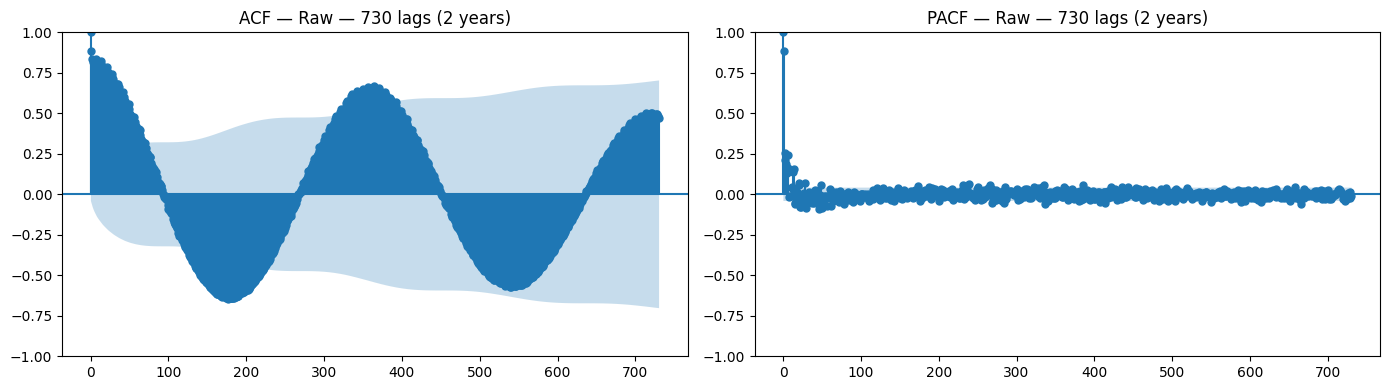

In [80]:
plot_acf_pacf(overall["total_rides"], lags=730, title="Raw — 730 lags (2 years)")

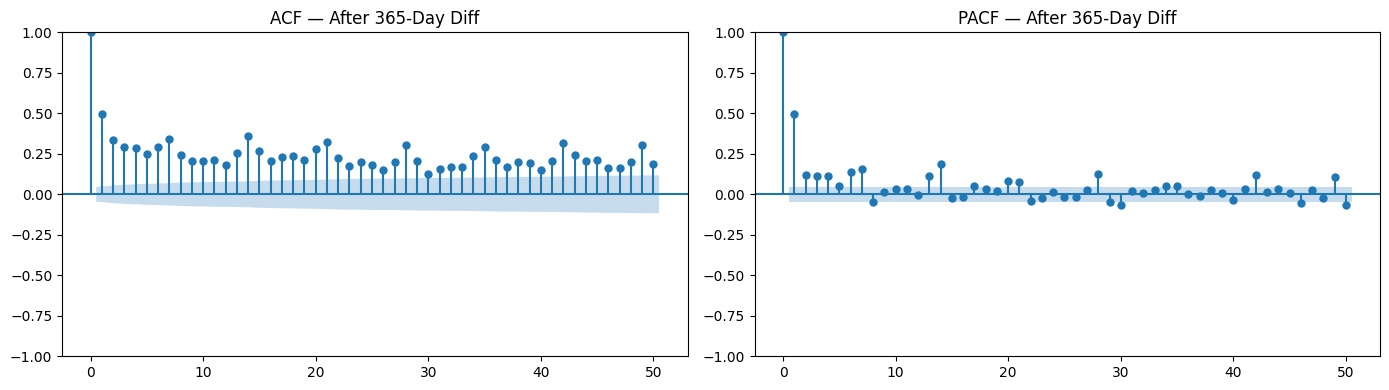

In [81]:
plot_acf_pacf(diff_365.dropna(), lags=50, title="After 365-Day Diff")

## 5. Station
### 5.1 Top Stations

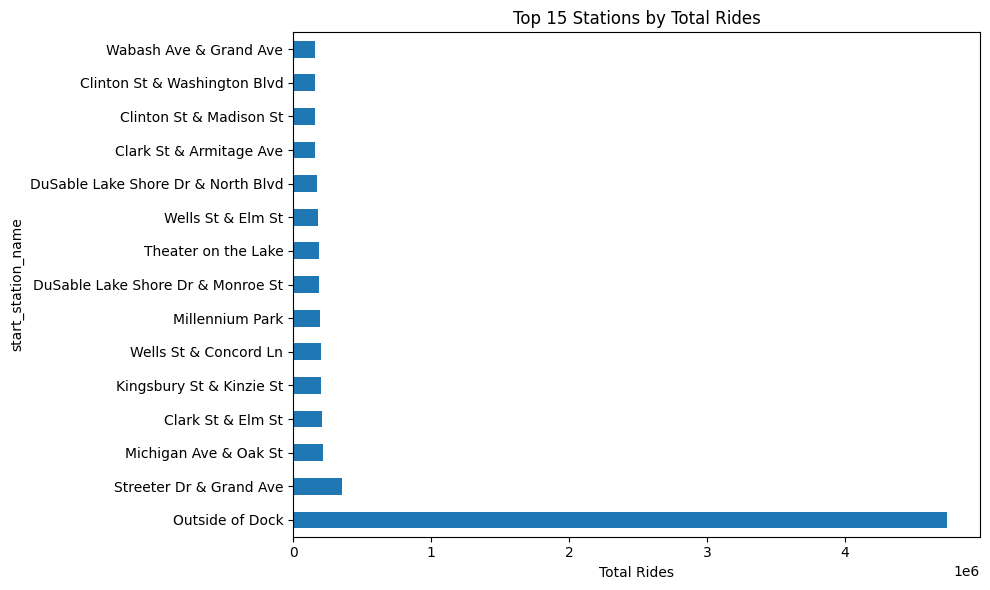

In [82]:
top_stations = (
    station.groupby("start_station_name")["total_rides"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
top_stations.plot.barh(figsize=(10, 6), title="Top 15 Stations by Total Rides")
plt.xlabel("Total Rides")
plt.tight_layout()
plt.show()

### 5.2 Station Ride Distribution

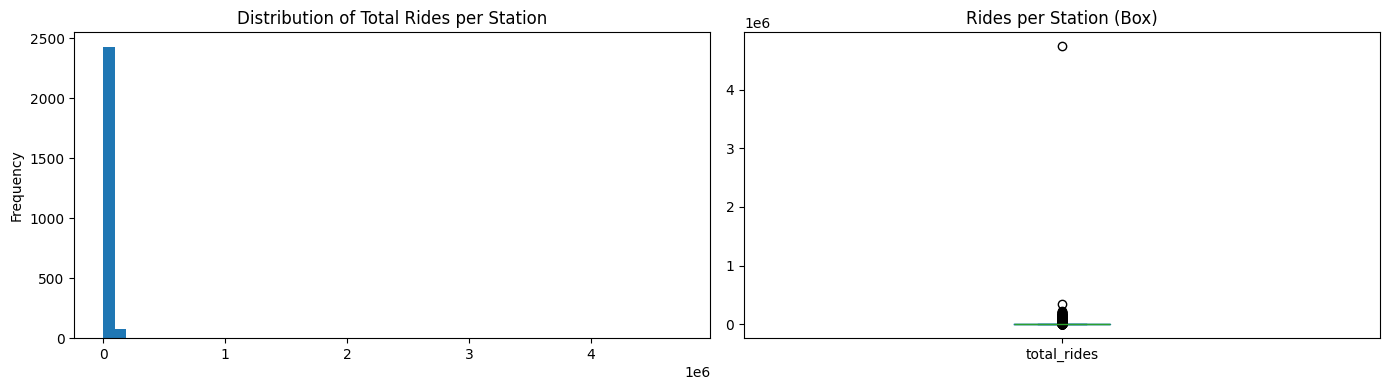

count    2.508000e+03
mean     1.284230e+04
std      9.874845e+04
min      1.000000e+00
25%      1.700000e+01
50%      1.830000e+02
75%      2.496500e+03
max      4.741785e+06
Name: total_rides, dtype: float64


In [83]:
station_totals = station.groupby("start_station_name")["total_rides"].sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
station_totals.plot.hist(bins=50, ax=axes[0], title="Distribution of Total Rides per Station")
station_totals.plot.box(ax=axes[1], title="Rides per Station (Box)")
plt.tight_layout()
plt.show()
print(station_totals.describe())

### 5.3 Outside of Dock

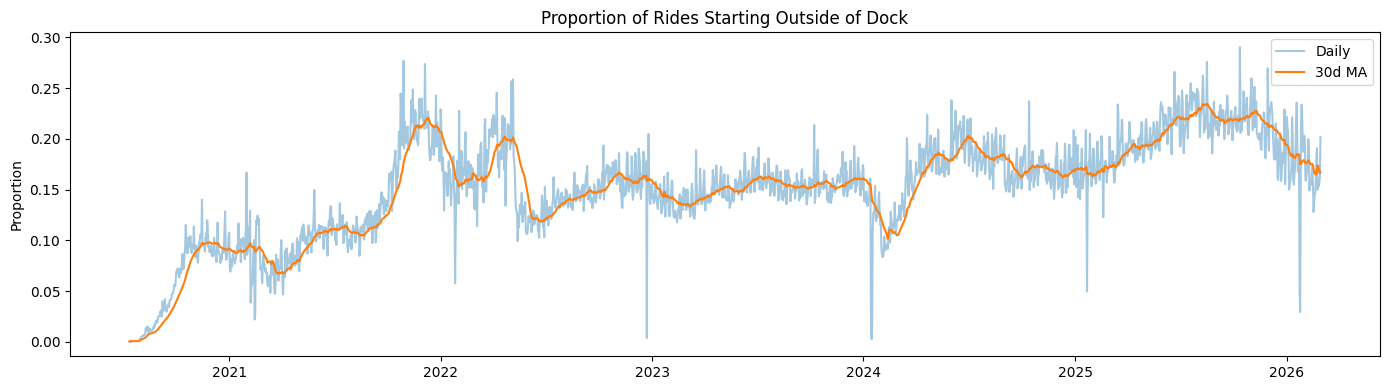

In [84]:
outside = station[station["start_station_name"] == "Outside of Dock"].set_index("date")
docked = station[station["start_station_name"] != "Outside of Dock"].groupby("date")["total_rides"].sum()

daily_outside = outside.groupby("date")["total_rides"].sum()
prop_outside = daily_outside / (daily_outside + docked)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prop_outside.index, prop_outside, alpha=0.4, label="Daily")
ax.plot(prop_outside.index, prop_outside.rolling(30, min_periods=1).mean(), label="30d MA")
ax.set_title("Proportion of Rides Starting Outside of Dock")
ax.set_ylabel("Proportion")
ax.legend()
plt.tight_layout()
plt.show()